# 导入必要的库

In [1]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split



# 设置随机种子，保证每次运行划分的数据是一样的（可复现性）
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("库加载完成，随机种子已设置。")

库加载完成，随机种子已设置。


#  读取数据，划分数据

确保数据的路径是

```txt
data/
    ├─georges
    └─non_georges
```

In [2]:
# 定义数据文件夹路径
DATA_DIR = "./data"
POS_DIR = os.path.join(DATA_DIR, "georges")
NEG_DIR = os.path.join(DATA_DIR, "non_georges")


# 获取所有图片的完整路径，并打上标签（1 代表正类，0 代表负类）
def get_image_paths_and_labels(folder_path, label):
    # 过滤出图片文件，防止混入隐藏文件如 .DS_Store
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    return [(os.path.join(folder_path, f), label) for f in os.listdir(folder_path) 
            if f.lower().endswith(valid_extensions)]

pos_data = get_image_paths_and_labels(POS_DIR, 1)
neg_data = get_image_paths_and_labels(NEG_DIR, 0)

all_data = pos_data + neg_data
all_paths = [item[0] for item in all_data]
all_labels = [item[1] for item in all_data]

print(f"总数据量: {len(all_paths)} (正类: {len(pos_data)}, 负类: {len(neg_data)})")


# 第一次划分：分出 70% 作为训练集，30% 留给验证和测试
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)


# 第二次划分：将剩下的 30% 平分，得到 15% 验证集和 15% 测试集
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"训练集大小: {len(train_paths)}")
print(f"验证集大小: {len(val_paths)}")
print(f"测试集大小: {len(test_paths)}")

总数据量: 5700 (正类: 2360, 负类: 3340)
训练集大小: 3990
验证集大小: 855
测试集大小: 855


# 数据增强（Transforms）

In [3]:
# ImageNet 的标准均值和标准差
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# 训练集的数据增强：增加各种随机干扰
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),               # 先放大一点
    transforms.RandomResizedCrop(224),           # 随机裁剪到 224x224
    transforms.RandomHorizontalFlip(p=0.5),      # 一半的概率水平翻转
    transforms.RandomRotation(degrees=15),       # 随机旋转最多 15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 稍微改变亮度和对比度
    transforms.ToTensor(),                       # 转换成 PyTorch 需要的张量 (Tensor)
    transforms.Normalize(mean, std)              # 标准化
])


# 验证集和测试集的处理：不能有随机干扰，只有基础缩放和标准化
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),               # 直接缩放到 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 自定义 PyTorch Dataset

In [4]:
class SaintGeorgeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # 返回数据集的总长度
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 根据索引 idx 获取一张图片和它的标签
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # 使用 PIL 打开图片。统一转成 RGB 防报错。
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"读取图片失败: {img_path}. 错误: {e}")
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

# 实例化三个数据集
train_dataset = SaintGeorgeDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = SaintGeorgeDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = SaintGeorgeDataset(test_paths, test_labels, transform=val_test_transforms)

print("数据集实例化完成。数据划分核对如下：")
print(f"  - 训练集装载了: {len(train_dataset)} 张图片")
print(f"  - 验证集装载了: {len(val_dataset)} 张图片")
print(f"  - 测试集装载了: {len(test_dataset)} 张图片")

数据集实例化完成。数据划分核对如下：
  - 训练集装载了: 3990 张图片
  - 验证集装载了: 855 张图片
  - 测试集装载了: 855 张图片


# 超参数

In [5]:
# 这个参数，  这个需要根据自己的硬件来。我的是  12G 显存
#BATCH_SIZE = 32 # 此时gpu占用 3.2G
# BATCH_SIZE=128   # 此时gpu占用 7.2G
BATCH_SIZE=16   #  EfficientNet 2步走，显存消耗大，我换成了   16


# 1. 自动选择硬件设备（如果有 NVIDIA 显卡就用 GPU，否则用 CPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 创建 DataLoader
# 注意：在 Windows+Jupyter 环境下，num_workers 必须设为 0，否则会引发多进程寻址报错
NUM_WORKERS = 0

# 创建 DataLoader 并在 Jupyter 中进行可视化验证


todo :

把这些超参数都放在一起，算是比较成熟的做法。容易找到，因为经常修改。

In [6]:


# 2. 核心优化：加入 pin_memory=True 极大地提升 CPU 到 GPU 的数据传输速度
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,     # 开启专属显存通道
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True      # 开启专属显存通道
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

print(f"数据加载器已更新: BATCH_SIZE = {BATCH_SIZE}, PIN_MEMORY = True")

数据加载器已更新: BATCH_SIZE = 128, PIN_MEMORY = True


# 查看一个图片。

正在从 DataLoader 中抽取一批数据进行可视化...


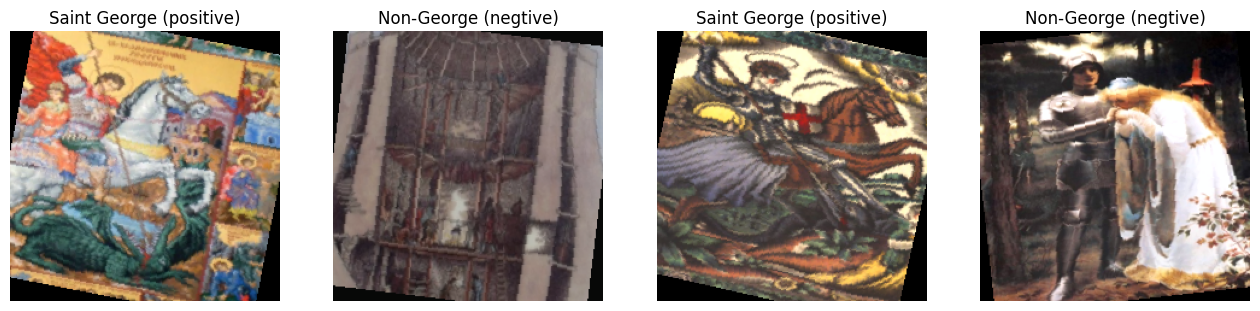

可视化完成！如果你能看到图片，说明数据准备阶段完美结束。


In [7]:

# 可视化一个 Batch 的函数
def imshow(inp, title=None):
    """反归一化并展示图片"""
    inp = inp.numpy().transpose((1, 2, 0)) # 将 PyTorch 的 (C, H, W) 转成 matplotlib 需要的 (H, W, C)
    mean_np = np.array(mean)
    std_np = np.array(std)
    inp = std_np * inp + mean_np # 反归一化
    inp = np.clip(inp, 0, 1)     # 限制像素值在 0 到 1 之间
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

print("正在从 DataLoader 中抽取一批数据进行可视化...")

# 从训练集加载器中拿出一个批次的数据
images, labels = next(iter(train_loader))

# 展示前 4 张图片
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    label_name = "Saint George (positive)" if labels[i].item() == 1.0 else "Non-George (negtive)"
    imshow(images[i], title=label_name)

plt.show()
print("可视化完成！如果你能看到图片，说明数据准备阶段完美结束。")

# 构建迁移学习模型  EfficientNet-V2

models.EfficientNet_V2_S_Weights.DEFAULT


## 为什么 EfficientNet-V2_S 容易卡？

- 输入分辨率较高（默认训练时 resize 到 384×384）
- 虽然参数量只有约 21.5M，但训练时的峰值显存（包括梯度、优化器状态、激活值）比同等参数的旧 EfficientNet 高
- batch_size=16 + 较高分辨率 在 12GB 显存上经常接近极限，尤其在训练（backward）阶段


### 换成：
- models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)


In [8]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

def build_efficientnet_b0():
    # 1. 加载轻量级冠军：EfficientNet_B0
    # 它默认接受 224x224 的输入，刚好匹配我们的 Dataset
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # 2. 不做任何冻结，全部层允许训练 (单阶段直接微调)
    for param in model.parameters():
        param.requires_grad = True
        
    # 3. 替换分类头，改为二分类
    # B0 的分类器结构也是 classifier[1] 是 Linear 层
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 1)
    
    return model

# 实例化模型并推入显卡
eff_b0_model = build_efficientnet_b0().to(device)
print("EfficientNet-B0 构建完成，所有层均已解冻，准备进行单阶段训练。")

EfficientNet-B0 构建完成，所有层均已解冻，准备进行单阶段训练。


# 配置训练三剑客（gpu、损失函数、优化器）

In [9]:
# 设置优化器：因为是整体解冻微调，学习率一定要保守，设置为 1e-4
optimizer_b0 = optim.AdamW(eff_b0_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 确保损失函数依然带有类别权重 (解决正负样本不平衡)
weight_value = 3340 / 2360
pos_weight = torch.tensor([weight_value]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 编写核心的训练与验证逻辑

In [10]:
import copy
import time

from tqdm.notebook import tqdm # 提供漂亮的进度条
from torch.optim.lr_scheduler import CosineAnnealingLR

### CosineAnnealingLR ??

def train_model_advanced(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, save_path="best_model.pth"):
    # 引入余弦退火学习率调度器：让学习率像平滑的波浪一样慢慢降下来
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} [LR: {scheduler.get_last_lr()[0]:.6f}]")
        print("-" * 15)
        
        start_time = time.time()

        # ---------------- 训练阶段 ----------------
        model.train()
        running_loss = 0.0
        correct_preds, total_preds = 0, 0
        
        for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            preds = torch.sigmoid(outputs) >= 0.5 
            correct_preds += torch.sum(preds == labels.byte()).item()
            total_preds += labels.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_preds / total_preds
        
        # 训练完一个 epoch，调度器更新学习率
        scheduler.step()

        # ---------------- 验证阶段 ----------------
        model.eval()
        val_running_loss = 0.0
        val_correct_preds, val_total_preds = 0, 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Validating", leave=False):
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                val_correct_preds += torch.sum(preds == labels.byte()).item()
                val_total_preds += labels.size(0)
                
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_acc = val_correct_preds / val_total_preds
        
        time_elapsed = time.time() - start_time
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}  ({time_elapsed:.0f}s)")
        
        # ---------------- 保存最优模型 ----------------
        if epoch_val_acc > best_acc:
            print(f"验证集准确率提升: {best_acc:.4f} -> {epoch_val_acc:.4f}. 保存模型！")
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, save_path)
            
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
    print(f"\n训练结束！最高验证集准确率: {best_acc:.4f}")
    # 训练结束后，把最好的记忆装回模型大脑里
    model.load_state_dict(best_model_wts)
    return model, history

print("升级版训练引擎准备完毕。")

升级版训练引擎准备完毕。


# 训练  1

### 第一阶段：配置只优化最后一层的优化器

这个阶段我们只跑 3 个 Epoch，目的只是让最后一层随机初始化的参数收敛到一个合理的位置。

In [11]:
print("--- 开始 EfficientNet-B0 单阶段微调测试 (8 Epochs) ---")
# 启动训练

best_b0_model, b0_history = train_model_advanced(
    model=eff_b0_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer_b0, 
    num_epochs=8, 
    save_path="effnet_b0_best.pth"
)


--- 开始 EfficientNet-B0 单阶段微调测试 (8 Epochs) ---

Epoch 1/8 [LR: 0.000100]
---------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.7287 | Train Acc: 0.6603
Val Loss:   0.5921 | Val Acc:   0.7661  (71s)
验证集准确率提升: 0.0000 -> 0.7661. 保存模型！

Epoch 2/8 [LR: 0.000096]
---------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.2895 | Train Acc: 0.8911
Val Loss:   0.2708 | Val Acc:   0.9099  (121s)
验证集准确率提升: 0.9041 -> 0.9099. 保存模型！

Epoch 8/8 [LR: 0.000004]
---------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.2709 | Train Acc: 0.9085
Val Loss:   0.2719 | Val Acc:   0.9088  (113s)

训练结束！最高验证集准确率: 0.9099


# 输出

--- 开始 EfficientNet-B0 单阶段微调测试 (8 Epochs) ---

Epoch 1/8 [LR: 0.000100]
---------------
Train Loss: 0.7287 | Train Acc: 0.6603
Val Loss:   0.5921 | Val Acc:   0.7661  (71s)
验证集准确率提升: 0.0000 -> 0.7661. 保存模型！

Epoch 2/8 [LR: 0.000096]
---------------
Train Loss: 0.5310 | Train Acc: 0.7984
Val Loss:   0.4056 | Val Acc:   0.8538  (79s)
验证集准确率提升: 0.7661 -> 0.8538. 保存模型！

Epoch 3/8 [LR: 0.000085]
---------------
Train Loss: 0.4091 | Train Acc: 0.8551
Val Loss:   0.3234 | Val Acc:   0.8889  (80s)
验证集准确率提升: 0.8538 -> 0.8889. 保存模型！

Epoch 4/8 [LR: 0.000069]
---------------
Train Loss: 0.3409 | Train Acc: 0.8778
Val Loss:   0.3056 | Val Acc:   0.8877  (86s)

Epoch 5/8 [LR: 0.000050]
---------------
Train Loss: 0.3086 | Train Acc: 0.8871
Val Loss:   0.2868 | Val Acc:   0.9041  (113s)
验证集准确率提升: 0.8889 -> 0.9041. 保存模型！

Epoch 6/8 [LR: 0.000031]
---------------
Train Loss: 0.2869 | Train Acc: 0.9002
Val Loss:   0.2779 | Val Acc:   0.9041  (87s)

Epoch 7/8 [LR: 0.000015]
---------------
Train Loss: 0.2895 | Train Acc: 0.8911
Val Loss:   0.2708 | Val Acc:   0.9099  (121s)
验证集准确率提升: 0.9041 -> 0.9099. 保存模型！

Epoch 8/8 [LR: 0.000004]
---------------
Train Loss: 0.2709 | Train Acc: 0.9085
Val Loss:   0.2719 | Val Acc:   0.9088  (113s)

训练结束！最高验证集准确率: 0.9099

# 分析结果，检查错误。

In [12]:


# 3. 错误分析：在测试集上寻找做错的题
def analyze_errors(model, test_loader):
    model.eval()
    misclassified_images = []
    misclassified_true_labels = []
    misclassified_pred_probs = []
    
    print("\n开始在测试集上进行错误分析...")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs_device = inputs.to(device)
            outputs = model(inputs_device)
            probs = torch.sigmoid(outputs).squeeze().cpu()
            preds = (probs >= 0.5).int()
            
            # 找出预测和真实标签不一致的索引
            for i in range(len(labels)):
                if preds[i] != int(labels[i].item()):
                    # 保存原图（反归一化方便展示）、真实标签、预测的概率
                    misclassified_images.append(inputs[i])
                    misclassified_true_labels.append(labels[i].item())
                    misclassified_pred_probs.append(probs[i].item())
                    
                    # 收集到 8 张错图就停止，方便可视化
                    if len(misclassified_images) >= 8:
                        break
            if len(misclassified_images) >= 8:
                break
                
    # 展示这 8 张错图
    if len(misclassified_images) > 0:
        print(f"抓到了错图！下面展示模型最容易弄错的样本：")
        fig = plt.figure(figsize=(16, 8))
        for i in range(len(misclassified_images)):
            ax = fig.add_subplot(2, 4, i+1)
            imshow(misclassified_images[i])
            true_l = "George" if misclassified_true_labels[i] == 1 else "Non-George"
            # 概率>0.5模型认为是George，<0.5认为是Non-George
            pred_prob = misclassified_pred_probs[i]
            pred_l = "George" if pred_prob >= 0.5 else "Non-George"
            plt.title(f"True: {true_l}\nPred: {pred_l}\nProb: {pred_prob:.2f}", 
                      color="red" if true_l != pred_l else "green")
        plt.tight_layout()
        plt.show()
    else:
        print("太不可思议了！在这批测试数据中居然一张都没错！")



In [14]:
# 运行错误分析
# analyze_errors(best_model, test_loader)